<a href="https://colab.research.google.com/github/adilaw-p/PINNs-2D-Transient-Heat-Conduction/blob/main/PINNs%202D%20Transient%20Heat%20Conduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Geometry**

Connecting to Google Drive
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Successfully connected to Google Drive
folder '/content/drive/MyDrive/PROJECT_2/Geometry' already exists in Drive.

Starting Geomtry Generation

Generating Geometry
Complete
Saved at: /content/drive/MyDrive/PROJECT_2/Geometry/Geometry.npy


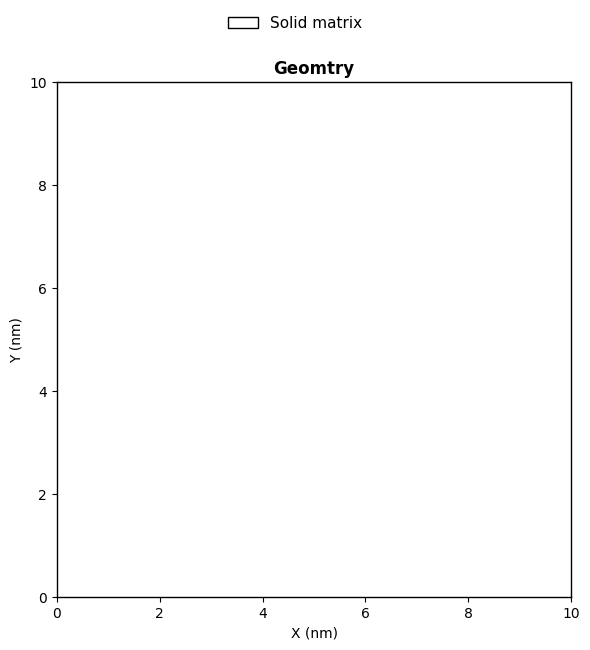


All processes completed. File 'Geometry.npy' has been saved to Google Drive.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

# MOUNT GOOGLE DRIVE
print("Connecting to Google Drive")
try:
  from google.colab import drive
  drive.mount('/content/drive')
  print("Successfully connected to Google Drive")
except importError:
  print("Can't connect to Google Drive, Saving locally.")

# CONFIGURATION & FOLDER PATH
BASE_PATH = "/content/drive/MyDrive/PROJECT_2"
OUTPUT_FOLDER = os.path.join(BASE_PATH, "Geometry")
GRID_SIZE = 256
DOMAIN_SIZE_nm = 10
if not os.path.exists(OUTPUT_FOLDER):
  os.makedirs(OUTPUT_FOLDER)
  print(f"folder '{OUTPUT_FOLDER}' created in Drive.")
else:
  print(f"folder '{OUTPUT_FOLDER}' already exists in Drive.")

# GENERATOR FUNCTION
def generate_solid_mask(grid_size):
  print(f"\nGenerating Geometry")
  # Create a geometry
  mask = np.ones((grid_size, grid_size), dtype=np.float32)
  filename = f"Geometry.npy"
  save_path = os.path.join(OUTPUT_FOLDER, filename)

  np.save(save_path, mask)
  print(f"Complete")
  print(f"Saved at: {save_path}")
  return mask, filename

# EXECUTION & VISUALIZATION
fig, axes = plt.subplots(1, 1, figsize=(6, 7.5), squeeze=False)
print("\nStarting Geomtry Generation")
mask_res, fname = generate_solid_mask(GRID_SIZE)

# GEOMTRY STRUCTURE VISUALIZATION
ax_geo = axes[0, 0]
ax_geo.imshow(mask_res, origin='lower', cmap='gray', extent=[0, DOMAIN_SIZE_nm, 0, DOMAIN_SIZE_nm], vmin=0, vmax=1)
ax_geo.set_title(f"Geomtry", fontweight='bold')
ax_geo.axis('on')
ax_geo.set_xlabel("X (nm)")
ax_geo.set_ylabel("Y (nm)")
for spine in ax_geo.spines.values():
  spine.set_edgecolor('black')
  spine.set_linewidth(1)

# LEGEND
solid_patch = mpatches.Patch(color='white', label='Solid matrix', ec='black', lw=1)

fig.legend(handles=[solid_patch],
           loc='upper center',
           ncol=2,
           fontsize=11,
           bbox_to_anchor=(0.5, 0.95),
           frameon=False)

plt.tight_layout()
plt.show()
print(f"\nAll processes completed. File '{fname}' has been saved to Google Drive.")

#**PINN & FEM code**

SIMULATION CONFIGURATION (OPTIMIZED TRANSIENT SOLID 2D)
Device in use: cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Successfully connected to Google Drive
Geometry File loaded: Geometry.npy

Generating High-Density Collocation Points...

--- Inisialisasi Training (Optimized Dual-Phase) ---
Mulai Phase 1: ADAM (5000 epochs)...
Ep 0: Total 6.1649e+03 | PDE 1.8255e+03 | LR 2.0e-03
Ep 1000: Total 4.5396e+00 | PDE 2.2899e+00 | LR 1.8e-03
Ep 2000: Total 2.0390e+00 | PDE 6.8477e-01 | LR 1.3e-03
Ep 3000: Total 1.4894e+00 | PDE 3.8487e-01 | LR 7.0e-04
Ep 4000: Total 1.3107e+00 | PDE 3.0121e-01 | LR 2.0e-04
Ep 4999: Total 1.2748e+00 | PDE 2.8565e-01 | LR 1.0e-05

Mulai Phase 2: L-BFGS (Max 5000 iter)...
L-BFGS Iter 500: Total 5.45545e-01 | PDE 1.32450e-01
L-BFGS Iter 1000: Total 1.72620e-01 | PDE 7.68431e-02
L-BFGS Iter 1500: Total 4.86608e-02 | PDE 2.85370e-02
L-BFGS Iter 2000: Total 1.91512e-02 | PDE 1.177

/tmp/ipykernel_1485/176803635.py:373: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.06, 1, 0.94])


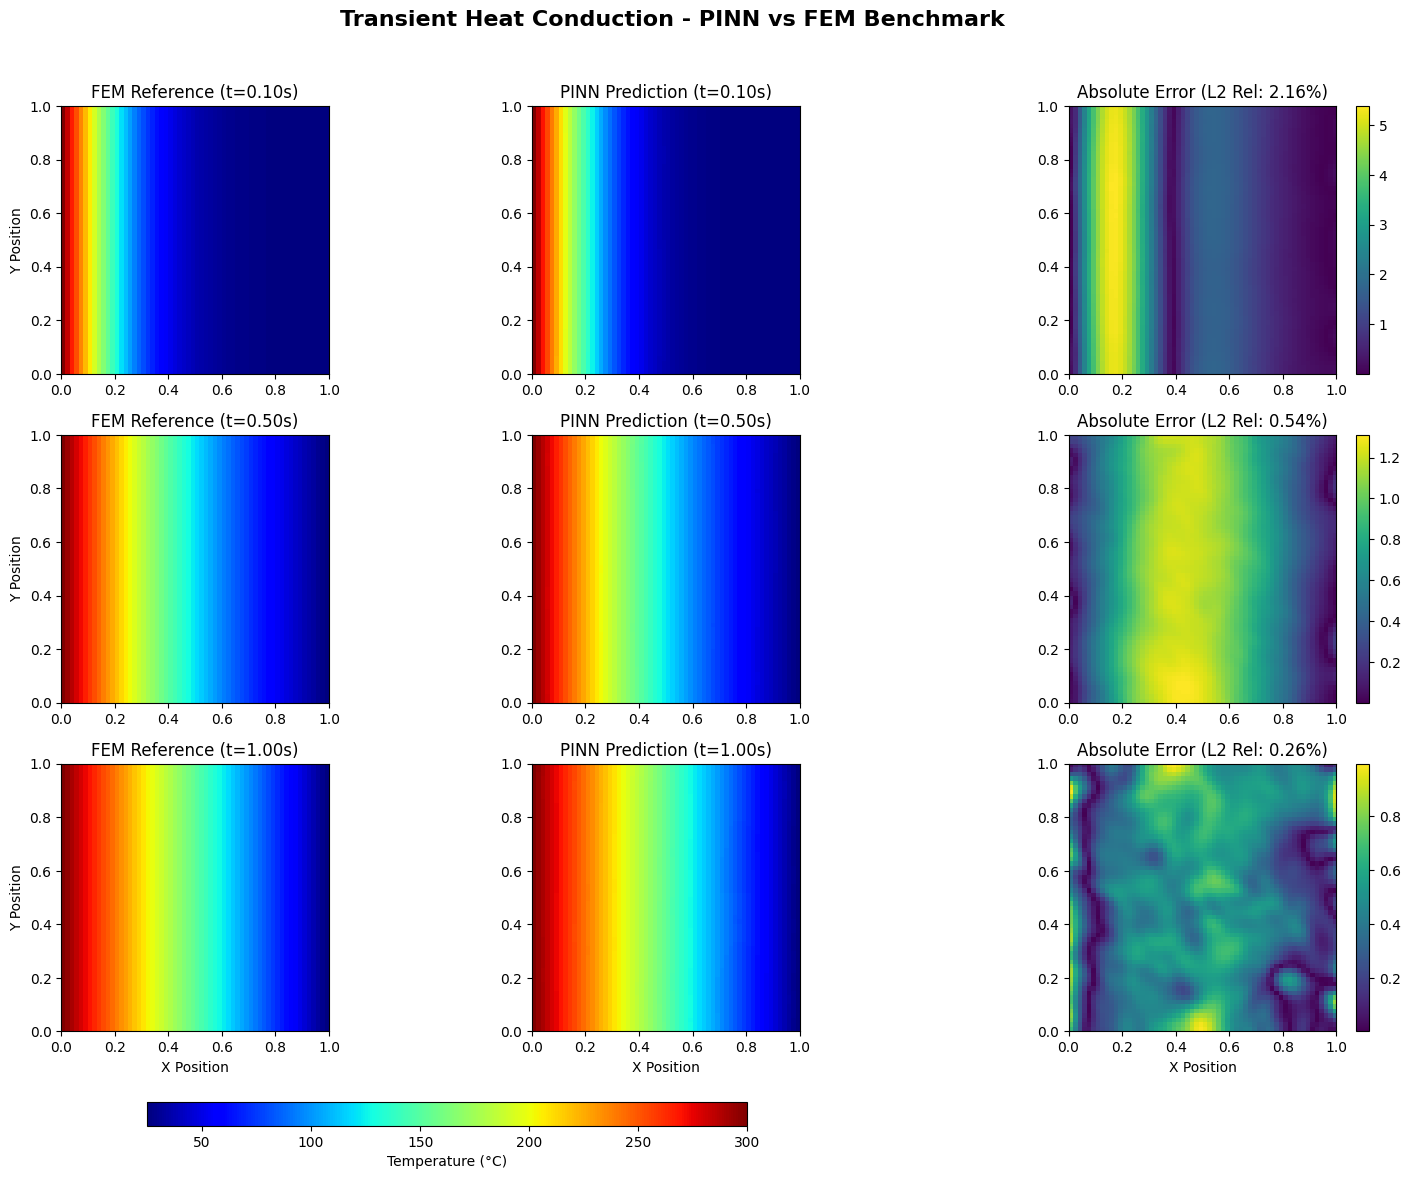

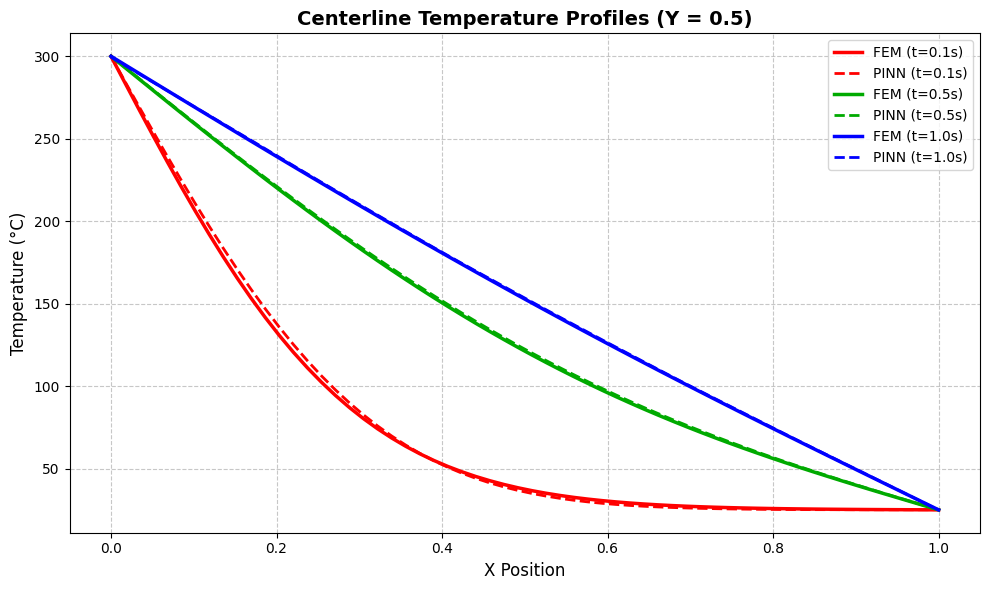

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import coo_matrix
from scipy.sparse.linalg import spsolve
from torch.nn.init import xavier_uniform_
import os
import time

# ==============================================================================
# SECTION 0: GLOBAL CONFIGURATION & PHYSICAL PARAMETERS
# ==============================================================================
print("SIMULATION CONFIGURATION (OPTIMIZED TRANSIENT SOLID 2D)")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device in use: {device}")

# Mount Google Drive
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Successfully connected to Google Drive")
except ImportError:
    print("Can't connect to Google Drive, saving locally.")

BASE_PATH = "/content/drive/MyDrive/PROJECT_2/Geometry"
GEO_FILE = os.path.join(BASE_PATH, "Geometry.npy")

T_HOT = 300.0
T_COLD = 25.0
T_INIT = 25.0
DELTA_T = T_HOT - T_COLD

# Parameter termal solid
ALPHA = 0.3  # Diffusivitas termal (k / (rho * cp))
X_MAX, Y_MAX = 1.0, 1.0
T_MAX = 1.0   # Total waktu simulasi

# Set Random Seeds for Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# ==============================================================================
# SECTION 1: LOAD GEOMETRY
# ==============================================================================
try:
    solid_mask = np.load(GEO_FILE)
    print(f"Geometry File loaded: {os.path.basename(GEO_FILE)}")
except FileNotFoundError:
    print(f"File geometry tidak ditemukan. Membuat grid 256x256 otomatis...")
    solid_mask = np.ones((256, 256), dtype=np.float32)

H_GRID, W_GRID = solid_mask.shape

# ==============================================================================
# SECTION 2: OPTIMIZED PINN ARCHITECTURE (FOURIER FEATURE EMBEDDING)
# ==============================================================================
class OptimizedTransientPINN(nn.Module):
    def __init__(self, num_fourier_features=64, scale=1.5):
        super().__init__()
        # Fourier Feature Mapping (3 input dimensions: x, y, t)
        self.B = torch.randn(3, num_fourier_features) * scale
        self.register_buffer('B_freq', self.B)

        # Deep MLP with Tanh activations
        in_dim = num_fourier_features * 2
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, 1)
        )
        self.apply(self.init_weights)

    def init_weights(self, m):
        if isinstance(m, nn.Linear):
            xavier_uniform_(m.weight)
            m.bias.data.fill_(0.0)

    def forward(self, x, y, t):
        inputs = torch.cat([x, y, t], dim=1)
        proj = 2.0 * np.pi * (inputs @ self.B_freq)
        inputs_embed = torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)
        output = self.net(inputs_embed)
        return output

# ==============================================================================
# SECTION 3: PHYSICS LOSS DEFINITION (TRANSIENT HEAT CONDUCTION)
# ==============================================================================
def physics_loss_transient(model, x, y, t):
    x.requires_grad_(True)
    y.requires_grad_(True)
    t.requires_grad_(True)

    T_pred = model(x, y, t)

    # Turunan waktu
    dT_dt = torch.autograd.grad(T_pred, t, grad_outputs=torch.ones_like(T_pred), create_graph=True)[0]

    # Turunan spasial orde-1
    dT_dx = torch.autograd.grad(T_pred, x, grad_outputs=torch.ones_like(T_pred), create_graph=True)[0]
    dT_dy = torch.autograd.grad(T_pred, y, grad_outputs=torch.ones_like(T_pred), create_graph=True)[0]

    # Turunan spasial orde-2
    d2T_dx2 = torch.autograd.grad(dT_dx, x, grad_outputs=torch.ones_like(dT_dx), create_graph=True)[0]
    d2T_dy2 = torch.autograd.grad(dT_dy, y, grad_outputs=torch.ones_like(dT_dy), create_graph=True)[0]

    # Residual PDE: dT/dt - alpha * (d2T/dx2 + d2T/dy2) = 0
    res_pde = dT_dt - ALPHA * (d2T_dx2 + d2T_dy2)
    loss_pde = torch.mean(res_pde**2)

    return loss_pde

# ==============================================================================
# SECTION 4: HIGH-DENSITY COLLOCATION & BOUNDARY SAMPLING
# ==============================================================================
print(f"\nGenerating High-Density Collocation Points...")

N_COL_SPATIAL = 60
N_COL_TIME = 30
N_BOUNDARY = 300
N_IC = 2500

# 1. Collocation Points inside Domain (Dense & Time-Clustered near t=0)
x_c = torch.rand(N_COL_SPATIAL * N_COL_SPATIAL * N_COL_TIME, 1)
y_c = torch.rand(N_COL_SPATIAL * N_COL_SPATIAL * N_COL_TIME, 1)
# Quadratic sampling untuk memperbanyak titik kolokasi di t awal
tau = torch.rand(N_COL_SPATIAL * N_COL_SPATIAL * N_COL_TIME, 1)
t_c = (tau ** 2) * T_MAX

x_col, y_col, t_col = x_c.to(device), y_c.to(device), t_c.to(device)

# 2. Boundary Points over Time
tb = torch.rand(N_BOUNDARY, 1) * T_MAX
xb = torch.linspace(0, 1, N_BOUNDARY).reshape(-1, 1)
yb = torch.linspace(0, 1, N_BOUNDARY).reshape(-1, 1)

XB_bound, TB_bound = torch.meshgrid(xb.squeeze(), tb.squeeze(), indexing='ij')
xb_flat = XB_bound.flatten()[:, None].to(device)
tb_flat = TB_bound.flatten()[:, None].to(device)

yb_flat = torch.rand_like(xb_flat).to(device)
xb_rand = torch.rand_like(yb_flat).to(device)

# 3. Initial Condition Points (t = 0)
X_ic, Y_ic = torch.meshgrid(torch.linspace(0, 1, 50), torch.linspace(0, 1, 50), indexing='ij')
x_ic = X_ic.flatten()[:, None].to(device)
y_ic = Y_ic.flatten()[:, None].to(device)
t_ic = torch.zeros_like(x_ic).to(device)

model = OptimizedTransientPINN().to(device)

# Loss Weights Optimization (Ketatan Syarat Batas & Kondisi Awal)
W_PDE = 1.0
W_BC  = 100.0
W_IC  = 100.0

loss_history = []

def closure_loss(optimizer=None):
    if optimizer: optimizer.zero_grad()

    # PDE Loss
    l_pde = physics_loss_transient(model, x_col, y_col, t_col)

    # Boundary Conditions (Hot Left: T=1.0, Cold Right: T=0.0)
    T_left = model(torch.zeros_like(xb_flat), yb_flat, tb_flat)
    T_right = model(torch.ones_like(xb_flat), yb_flat, tb_flat)
    l_bc_l = torch.mean((T_left - 1.0)**2)
    l_bc_r = torch.mean((T_right - 0.0)**2)

    # Insulated Top and Bottom (dT/dy = 0)
    y_top = torch.ones_like(xb_rand).requires_grad_(True)
    T_top = model(xb_rand, y_top, tb_flat)
    dT_dy_top = torch.autograd.grad(T_top, y_top, grad_outputs=torch.ones_like(T_top), create_graph=True)[0]

    y_btm = torch.zeros_like(xb_rand).requires_grad_(True)
    T_btm = model(xb_rand, y_btm, tb_flat)
    dT_dy_btm = torch.autograd.grad(T_btm, y_btm, grad_outputs=torch.ones_like(T_btm), create_graph=True)[0]

    l_bc_tb = torch.mean(dT_dy_top**2) + torch.mean(dT_dy_btm**2)

    # Initial Condition Loss (t = 0, T = 0.0)
    T_initial = model(x_ic, y_ic, t_ic)
    l_ic = torch.mean((T_initial - 0.0)**2)

    total_loss = (W_PDE * l_pde) + (W_BC * (l_bc_l + l_bc_r + l_bc_tb)) + (W_IC * l_ic)

    if optimizer: total_loss.backward()
    return total_loss, l_pde

# ==============================================================================
# SECTION 5: TRAINING LOOP (TWO-PHASE HYBRID OPTIMIZATION)
# ==============================================================================
print(f"\n--- Inisialisasi Training (Optimized Dual-Phase) ---")

# PHASE 1: ADAM OPTIMIZER WITH COSINE ANNEALING
ADAM_EPOCHS = 5000
optimizer_adam = torch.optim.Adam(model.parameters(), lr=2e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_adam, T_max=ADAM_EPOCHS, eta_min=1e-5)

print(f"Mulai Phase 1: ADAM ({ADAM_EPOCHS} epochs)...")
start_time = time.time()

for epoch in range(ADAM_EPOCHS):
    loss, lpde = closure_loss(optimizer_adam)
    optimizer_adam.step()
    scheduler.step()

    loss_history.append(loss.item())

    if epoch % 1000 == 0 or epoch == ADAM_EPOCHS - 1:
        print(f"Ep {epoch}: Total {loss.item():.4e} | PDE {lpde.item():.4e} | LR {scheduler.get_last_lr()[0]:.1e}")

# PHASE 2: HIGH-PRECISION L-BFGS OPTIMIZER
print(f"\nMulai Phase 2: L-BFGS (Max 5000 iter)...")
optimizer_lbfgs = torch.optim.LBFGS(
    model.parameters(),
    lr=1.0, max_iter=5000, max_eval=5000, history_size=100,
    tolerance_grad=1e-9, tolerance_change=1e-11, line_search_fn="strong_wolfe"
)

def closure_lbfgs_wrapper():
    optimizer_lbfgs.zero_grad()
    total_loss, l_pde = closure_loss(optimizer=None)
    total_loss.backward()

    if not hasattr(closure_lbfgs_wrapper, "iter_count"):
        closure_lbfgs_wrapper.iter_count = 0
    closure_lbfgs_wrapper.iter_count += 1

    loss_history.append(total_loss.item())

    if closure_lbfgs_wrapper.iter_count % 500 == 0:
        print(f"L-BFGS Iter {closure_lbfgs_wrapper.iter_count}: Total {total_loss.item():.5e} | PDE {l_pde.item():.5e}")

    return total_loss

closure_lbfgs_wrapper.iter_count = 0
optimizer_lbfgs.step(closure_lbfgs_wrapper)

end_time = time.time()
print(f"\nTraining Selesai. Total Waktu Training PINN: {(end_time - start_time)/60:.2f} menit")

# ==============================================================================
# SECTION 6: TRANSIENT FEM BENCHMARK (BACKWARD EULER Q4)
# ==============================================================================
print(f"\nExecuting Numerical Benchmark (Transient FEM)...")

def solve_fem_transient(N_grid, Nt, t_max):
    M_nodes = N_grid
    dx = 1.0 / (M_nodes - 1)
    num_nodes = M_nodes * M_nodes
    node_idx = np.arange(num_nodes).reshape(M_nodes, M_nodes)

    n1 = node_idx[:-1, :-1].flatten()
    n2 = node_idx[:-1, 1:].flatten()
    n3 = node_idx[1:, 1:].flatten()
    n4 = node_idx[1:, :-1].flatten()
    elements = np.stack([n1, n2, n3, n4], axis=1)

    K_base = (1.0 / 6.0) * np.array([
        [ 4.0, -1.0, -2.0, -1.0],
        [-1.0,  4.0, -1.0, -2.0],
        [-2.0, -1.0,  4.0, -1.0],
        [-1.0, -2.0, -1.0,  4.0]
    ])

    M_base = (dx * dx / 36.0) * np.array([
        [4.0, 2.0, 1.0, 2.0],
        [2.0, 4.0, 2.0, 1.0],
        [1.0, 2.0, 4.0, 2.0],
        [2.0, 1.0, 2.0, 4.0]
    ])

    I = np.repeat(elements, 4, axis=1).flatten()
    J = np.tile(elements, (1, 4)).flatten()

    V_K = np.tile(K_base.flatten(), len(elements))
    V_M = np.tile(M_base.flatten(), len(elements))

    K_global = coo_matrix((V_K, (I, J)), shape=(num_nodes, num_nodes)).tocsr()
    M_global = coo_matrix((V_M, (I, J)), shape=(num_nodes, num_nodes)).tocsr()

    dt = t_max / Nt
    A = M_global + (dt * ALPHA * K_global)
    A = A.tolil()

    left_nodes = node_idx[:, 0]
    right_nodes = node_idx[:, -1]

    for n in left_nodes:
        A[n, :] = 0.0; A[n, n] = 1.0
    for n in right_nodes:
        A[n, :] = 0.0; A[n, n] = 1.0

    A_csr = A.tocsr()
    T_current = np.zeros(num_nodes)
    T_history = [T_current.copy()]

    for step in range(1, Nt + 1):
        b = M_global.dot(T_current)
        b[left_nodes] = 1.0   # T_HOT Normalized
        b[right_nodes] = 0.0  # T_COLD Normalized
        T_next = spsolve(A_csr, b)
        T_current = T_next.copy()
        T_history.append(T_current.copy())

    return np.array(T_history).reshape(Nt + 1, M_nodes, M_nodes)

N_VAL = 60
N_TIME_STEPS = 60
T_fem_history = solve_fem_transient(N_VAL, N_TIME_STEPS, T_MAX)

# ==============================================================================
# SECTION 7: VISUALIZATION & ERROR METRICS CALCULATION
# ==============================================================================
print(f"\nGenerating Transient Visual Comparison & Calculating L2 Relative Error...")

time_indices = [int(N_TIME_STEPS * 0.1), int(N_TIME_STEPS * 0.5), N_TIME_STEPS]
eval_times = [(i / N_TIME_STEPS) * T_MAX for i in time_indices]

x_val = np.linspace(0, 1, N_VAL)
y_val = np.linspace(0, 1, N_VAL)
X_val, Y_val = np.meshgrid(x_val, y_val)
xv = torch.tensor(X_val.flatten()[:,None], dtype=torch.float32, device=device)
yv = torch.tensor(Y_val.flatten()[:,None], dtype=torch.float32, device=device)

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Transient Heat Conduction - PINN vs FEM Benchmark', fontsize=16, fontweight='bold', y=0.96)

model.eval()
with torch.no_grad():
    for row, (idx, t_val) in enumerate(zip(time_indices, eval_times)):
        # FEM Ground Truth
        T_fem_real = (T_fem_history[idx] * DELTA_T) + T_COLD

        # PINN Prediction
        tv = torch.ones_like(xv) * t_val
        T_pinn_norm = model(xv, yv, tv).cpu().numpy().reshape(N_VAL, N_VAL)
        T_pinn_real = (T_pinn_norm * DELTA_T) + T_COLD

        # Absolute Error
        error_map = np.abs(T_fem_real - T_pinn_real)

        # Relative L2 Error Computation
        l2_relative_err = np.linalg.norm(T_pinn_real - T_fem_real) / np.linalg.norm(T_fem_real)
        mae = np.mean(error_map)

        print(f"Time t = {t_val:.2f}s | Relative L2 Error: {l2_relative_err:.4e} ({l2_relative_err*100:.3f}%) | MAE: {mae:.4f}°C")

        # Plotting FEM
        im0 = axes[row, 0].imshow(T_fem_real, origin='lower', extent=[0,1,0,1], cmap='jet', vmin=T_COLD, vmax=T_HOT)
        axes[row, 0].set_title(f'FEM Reference (t={t_val:.2f}s)')
        if row == 2: axes[row, 0].set_xlabel('X Position')
        axes[row, 0].set_ylabel('Y Position')

        # Plotting PINN
        im1 = axes[row, 1].imshow(T_pinn_real, origin='lower', extent=[0,1,0,1], cmap='jet', vmin=T_COLD, vmax=T_HOT)
        axes[row, 1].set_title(f'PINN Prediction (t={t_val:.2f}s)')
        if row == 2: axes[row, 1].set_xlabel('X Position')

        # Plotting Absolute Error
        im2 = axes[row, 2].imshow(error_map, origin='lower', extent=[0,1,0,1], cmap='viridis')
        axes[row, 2].set_title(f'Absolute Error (L2 Rel: {l2_relative_err*100:.2f}%)')
        if row == 2: axes[row, 2].set_xlabel('X Position')
        plt.colorbar(im2, ax=axes[row, 2], fraction=0.046, pad=0.04)

cbar_ax = fig.add_axes([0.15, 0.03, 0.4, 0.02])
fig.colorbar(im0, cax=cbar_ax, orientation='horizontal', label='Temperature (°C)')

plt.tight_layout(rect=[0, 0.06, 1, 0.94])
plt.show()

# ==============================================================================
# SECTION 8: 1D CENTERLINE COMPARISON (Y = 0.5)
# ==============================================================================
plt.figure(figsize=(10, 6))
mid_y_idx = N_VAL // 2

# Definisikan target waktu dan warna secara eksplisit agar mudah dibaca
target_times = [0.1, 0.5, 1.0]
colors = ['#FF0000', '#00AA00', '#0000FF']  # Merah (0.1s), Hijau (0.5s), Biru (1.0s)

model.eval()
with torch.no_grad():
    for i, t_val in enumerate(target_times):
        # Mencari indeks pada matriks FEM yang sesuai dengan t_val
        idx = int((t_val / T_MAX) * N_TIME_STEPS)

        # Ekstrak suhu centerline dari hasil FEM (denormalisasi)
        T_fem_slice = (T_fem_history[idx][mid_y_idx, :] * DELTA_T) + T_COLD

        # Prediksi suhu centerline dari PINN (denormalisasi)
        tv = torch.ones_like(xv) * t_val
        T_pinn_slice_norm = model(xv, yv, tv).cpu().numpy().reshape(N_VAL, N_VAL)[mid_y_idx, :]
        T_pinn_slice = (T_pinn_slice_norm * DELTA_T) + T_COLD

        # Plot FEM (Garis Solid) dan PINN (Garis Putus-putus) dengan warna yang sama per-waktu
        plt.plot(x_val, T_fem_slice, '-', color=colors[i], linewidth=2.5,
                 label=f'FEM (t={t_val}s)')
        plt.plot(x_val, T_pinn_slice, '--', color=colors[i], linewidth=2.0,
                 label=f'PINN (t={t_val}s)')

plt.title("Centerline Temperature Profiles (Y = 0.5)", fontsize=14, fontweight='bold')
plt.xlabel("X Position", fontsize=12)
plt.ylabel("Temperature (°C)", fontsize=12)

# Mengatur letak legend menjadi 2 kolom agar rapi berdampingan (FEM kiri, PINN kanan)
plt.legend(loc='upper right', ncol=1, fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()